# <span style="font-size:16pt; font-weight:bold;">Notebook 25: Comprehensive Feature and Modality Importance</span>

**Purpose:** Feature importance analysis using CatBoost built-in importance, modality-aggregated importance, SHAP analysis, with features labeled by modality block.


## <span style="font-size:14pt; font-weight:bold;">1. Setup</span>


In [ ]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from pathlib import Path; import joblib; import warnings; warnings.filterwarnings('ignore')
REPO=Path.home()/'projects'/'music-prediction'
IMGS=REPO/'results/figures/thesis'; ANALYSIS=REPO/'results/analysis'; FEAT=REPO/'ml/features'; MDL=REPO/'ml/models/saved/thesis_ml_test'
IMGS.mkdir(parents=True,exist_ok=True); ANALYSIS.mkdir(parents=True,exist_ok=True)
TARGETS=['valence','energy','danceability','popularity']; TLABELS=['Valence','Energy','Danceability','Popularity']
TC={'valence':'#4C72B0','energy':'#DD8452','danceability':'#55A868','popularity':'#C44E52'}
# Modality blocks matching thesis_ml_models.py
MODALITIES=[('audio','Audio',23),('text_stats','Text Stats',5),('sentiment','Sentiment',2),('mpnet','MPNet',768),('vggish','VGGish',128),('mert','MERT',768),('panns','PANNs',2048),('mel_stats','Mel Stats',512)]
mod_ranges={}; start=0
for key,label,dim in MODALITIES: mod_ranges[label]=(start,start+dim); start+=dim
assert start==4254
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':300,'savefig.bbox':'tight','font.size':12,'axes.labelsize':14,'axes.titlesize':14})
print('Setup complete. Modality ranges:')
for l,(s,e) in mod_ranges.items(): print(f'  {l:<14}: {s}:{e} ({e-s} features)')


Setup complete. Modality ranges:
  Audio         : 0:23 (23 features)
  Text Stats    : 23:28 (5 features)
  Sentiment     : 28:30 (2 features)
  MPNet         : 30:798 (768 features)
  VGGish        : 798:926 (128 features)
  MERT          : 926:1694 (768 features)
  PANNs         : 1694:3742 (2048 features)
  Mel Stats     : 3742:4254 (512 features)


## <span style="font-size:14pt; font-weight:bold;">2. Load Models and Features</span>


In [ ]:
# Load CatBoost tuned models
models={}
for t in TARGETS:
    p=MDL/f'CatBoost_tuned_{t}.pkl'
    if p.exists(): models[t]=joblib.load(p); print(f'Loaded CatBoost_tuned_{t}')
    else:
        p2=MDL/f'CatBoost_{t}.pkl'
        if p2.exists(): models[t]=joblib.load(p2); print(f'Loaded CatBoost_{t} (fallback)')
        else: print(f'Not found: {p}')
if not models:
    print('No models found. Using dummy data.'); dummy=True
    for t in TARGETS: models[t]={'dummy':True}
else: dummy=False


Loaded CatBoost_tuned_valence
Loaded CatBoost_tuned_energy
Loaded CatBoost_tuned_danceability
Loaded CatBoost_tuned_popularity


In [ ]:
# Load test features
arrays=[]
for key,label,dim in MODALITIES:
    arr=np.load(FEAT/f'X_test_{key}.npy').astype(np.float32)
    assert arr.shape[1]==dim,f'{label}: expected {dim}, got {arr.shape[1]}'
    arrays.append(arr); print(f'  {label:<14}: {arr.shape}')
X_test=np.hstack(arrays).astype(np.float32); print(f'\nX_test shape: {X_test.shape}')
y_test={t:np.load(FEAT/f'y_test_{t}.npy') for t in TARGETS}


  Audio         : (74573, 23)
  Text Stats    : (74573, 5)
  Sentiment     : (74573, 2)
  MPNet         : (74573, 768)
  VGGish        : (74573, 128)
  MERT          : (74573, 768)
  PANNs         : (74573, 2048)
  Mel Stats     : (74573, 512)

X_test shape: (74573, 4254)


In [ ]:
# Build feature names list: audio names from file, rest as Modality[idx]
feature_names=[]
audio_feature_names=[
    'acousticness','instrumentalness','speechiness','liveness','loudness','tempo','duration_ms',
    'year','mode','key_sin','key_cos','genre_Blues','genre_Classical','genre_Country',
    'genre_Electronic','genre_Folk','genre_Hip-Hop','genre_Jazz','genre_Pop','genre_R&B',
    'genre_Rock','log_total_artist_followers','avg_artist_popularity']
for key,label,dim in MODALITIES:
    if key=='audio':
        assert len(audio_feature_names)==dim,f'Expected {dim} audio names, got {len(audio_feature_names)}'
        feature_names.extend(audio_feature_names)
    else:
        feature_names.extend([f'{label}[{j}]' for j in range(dim)])
print(f'Total feature names: {len(feature_names)}'); assert len(feature_names)==4254


Total feature names: 4254


## <span style="font-size:14pt; font-weight:bold;">3. CatBoost Feature Importance: Top-20 per Target</span>

Features are labeled by modality block (e.g., `PANNs[42]`, `Audio[genre_Rock]`). Color indicates modality origin.


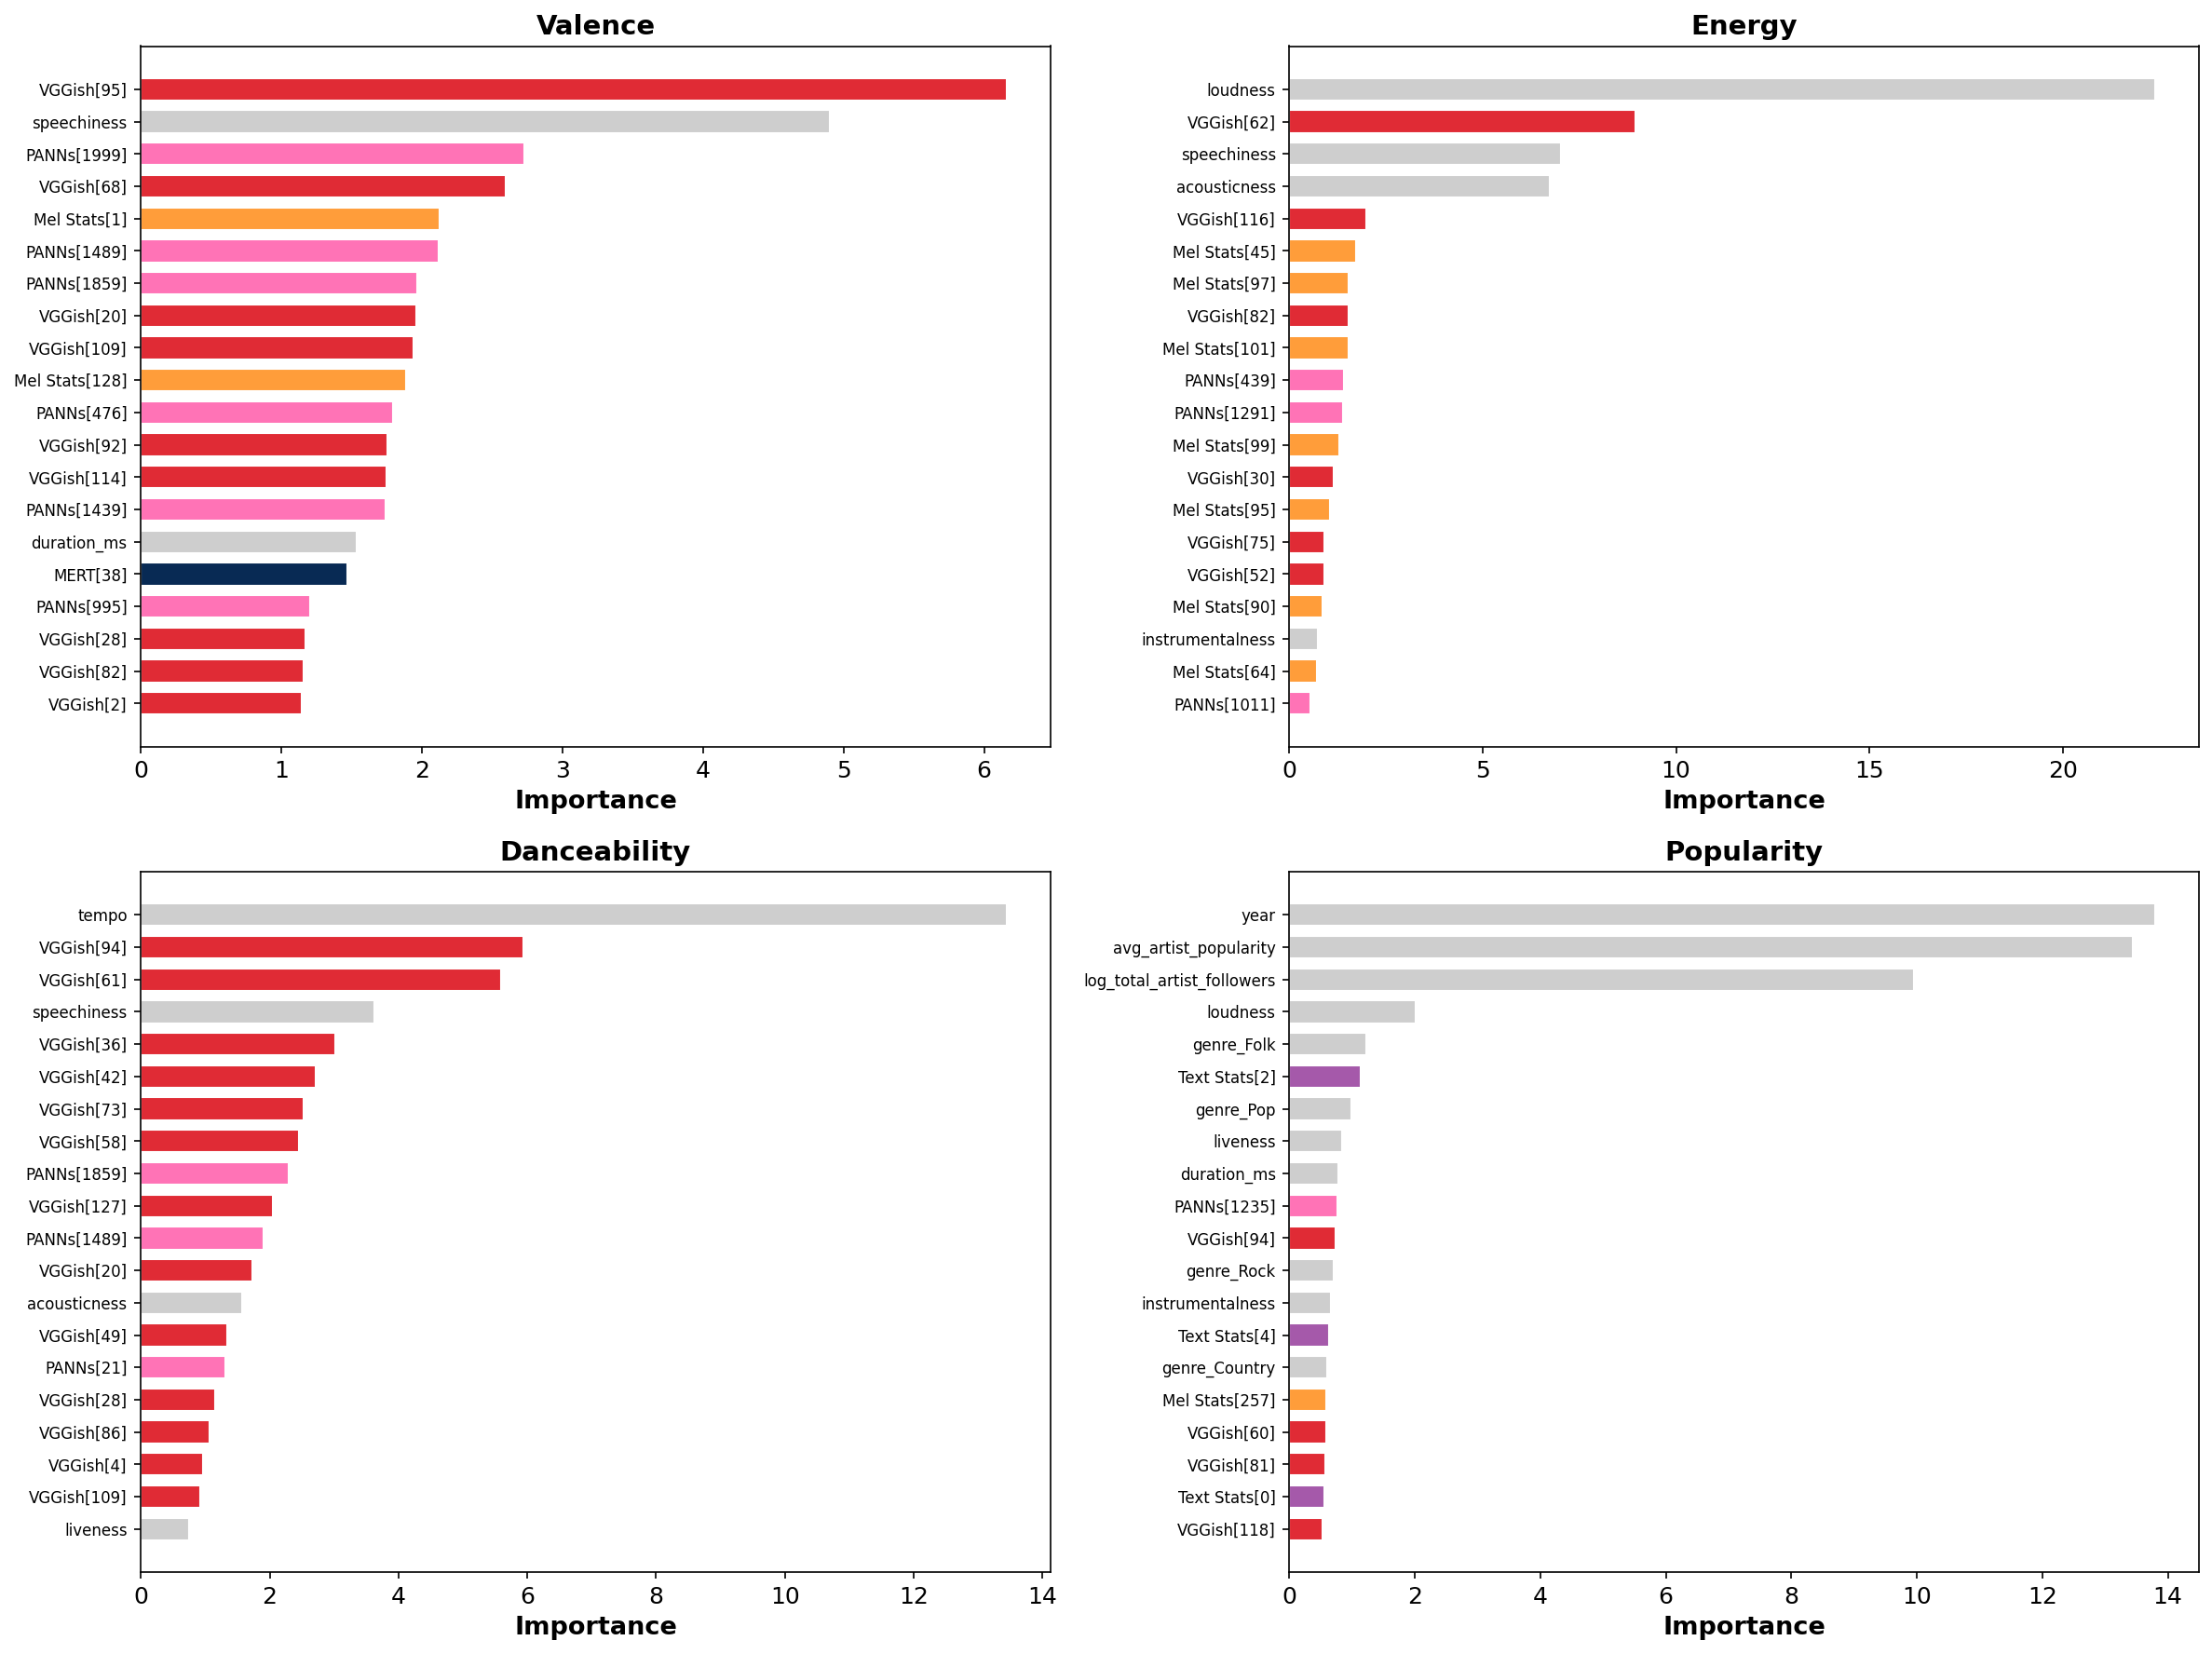

Saved: 25_top20_features.png


In [ ]:
if not dummy:
    imp={}
    for t in TARGETS: imp[t]=models[t].get_feature_importance()
    # Modality colors for 8 blocks
    mod_colors=['#CECECE','#A559AA','#59A89C','#F9E858','#E02B35','#082A54','#FF73B6','#FF9D3A']
    fig,axes=plt.subplots(2,2,figsize=(16,12))
    for idx,t in enumerate(TARGETS):
        ax=axes[idx//2,idx%2]; top_idx=np.argsort(imp[t])[-20:][::-1]; top_imp=imp[t][top_idx]
        top_names=[feature_names[i] for i in top_idx]
        # Color each bar by its modality
        bar_colors=[]
        for fi in top_idx:
            for (ml,(s,e)),mc in zip(mod_ranges.items(),mod_colors):
                if s<=fi<e: bar_colors.append(mc); break
        bars=ax.barh(range(20),top_imp,color=bar_colors,edgecolor='white',height=0.7)
        ax.set_yticks(range(20)); ax.set_yticklabels(top_names,fontsize=8); ax.invert_yaxis()
        ax.set_title(f'{TLABELS[idx]}',fontsize=14,fontweight='bold')
        ax.set_xlabel('Importance',fontsize=13,fontweight='bold')
    plt.tight_layout(); fig.savefig(IMGS/'25_top20_features.png'); plt.show()
    print('Saved: 25_top20_features.png')
else: print('Skipping: no models loaded')


## <span style="font-size:14pt; font-weight:bold;">4. Modality Contribution</span>

Aggregate CatBoost feature importance by modality block to show which data sources drive each target.


Modality Contribution (%)
              Audio  Text Stats  Sentiment  MPNet  VGGish   MERT  PANNs  Mel Stats
Valence        9.59        0.97       0.01   2.10   32.29  17.17  26.17      11.71
Energy        38.40        0.32       0.00   0.48   24.05   6.56  11.93      18.25
Danceability  22.13        1.24       0.01   1.74   43.72   8.62  17.54       5.00
Popularity    46.92        2.60       0.01  11.43   16.29   5.21  11.06       6.48


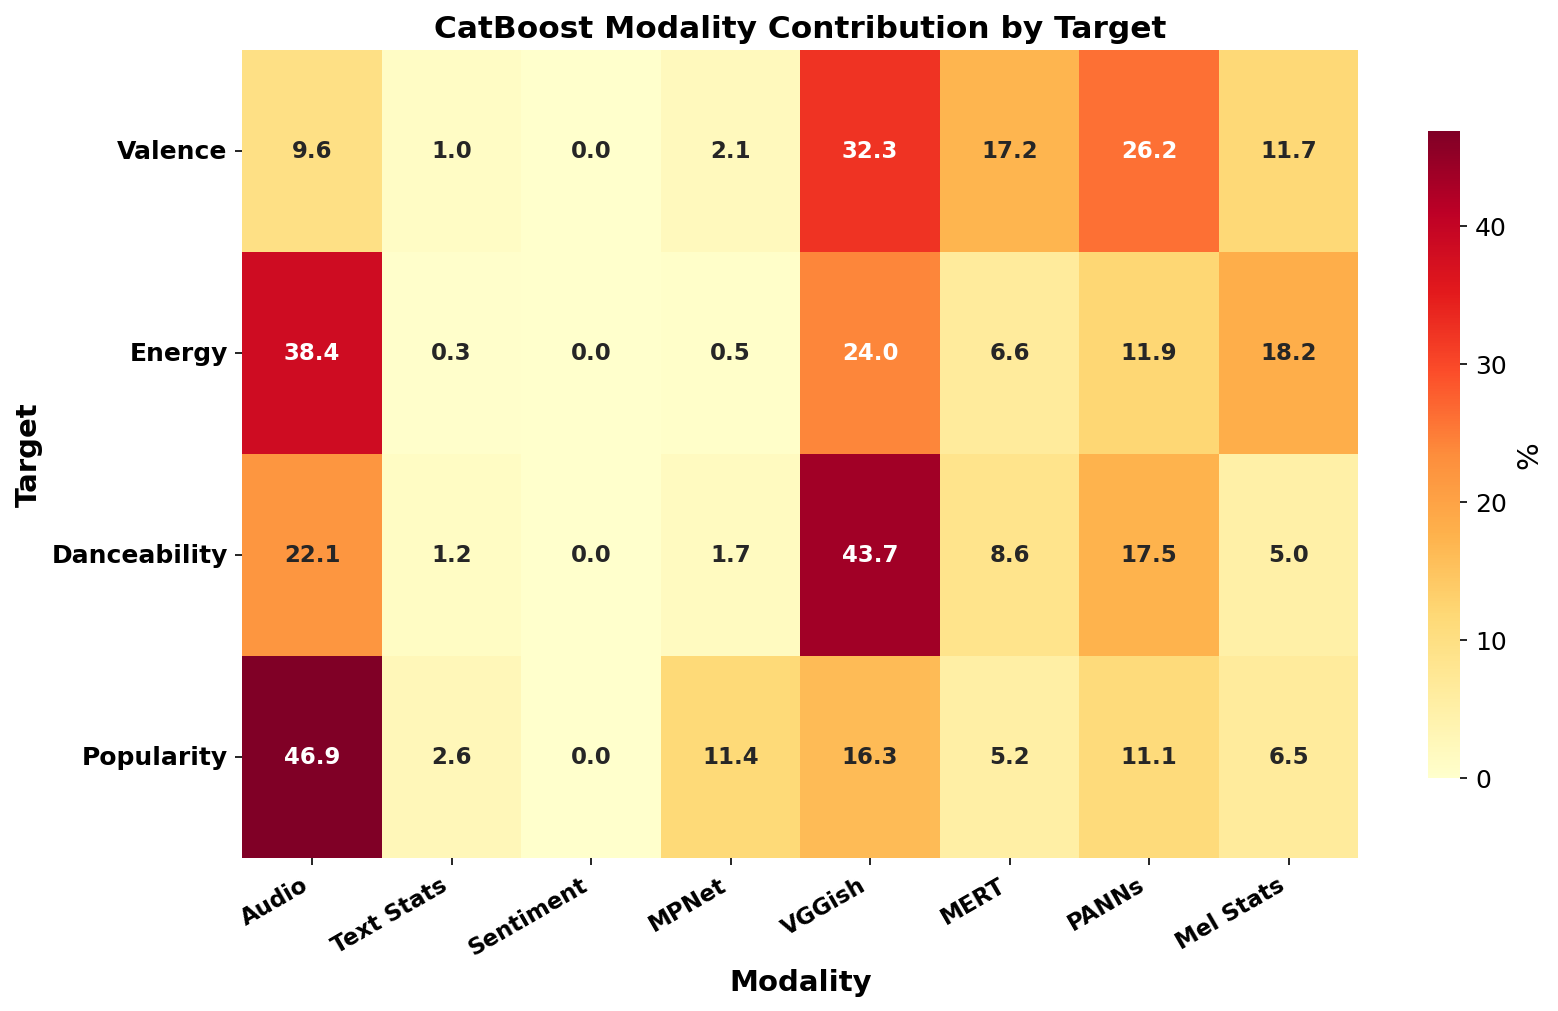

Saved: 25_modality_contribution.png


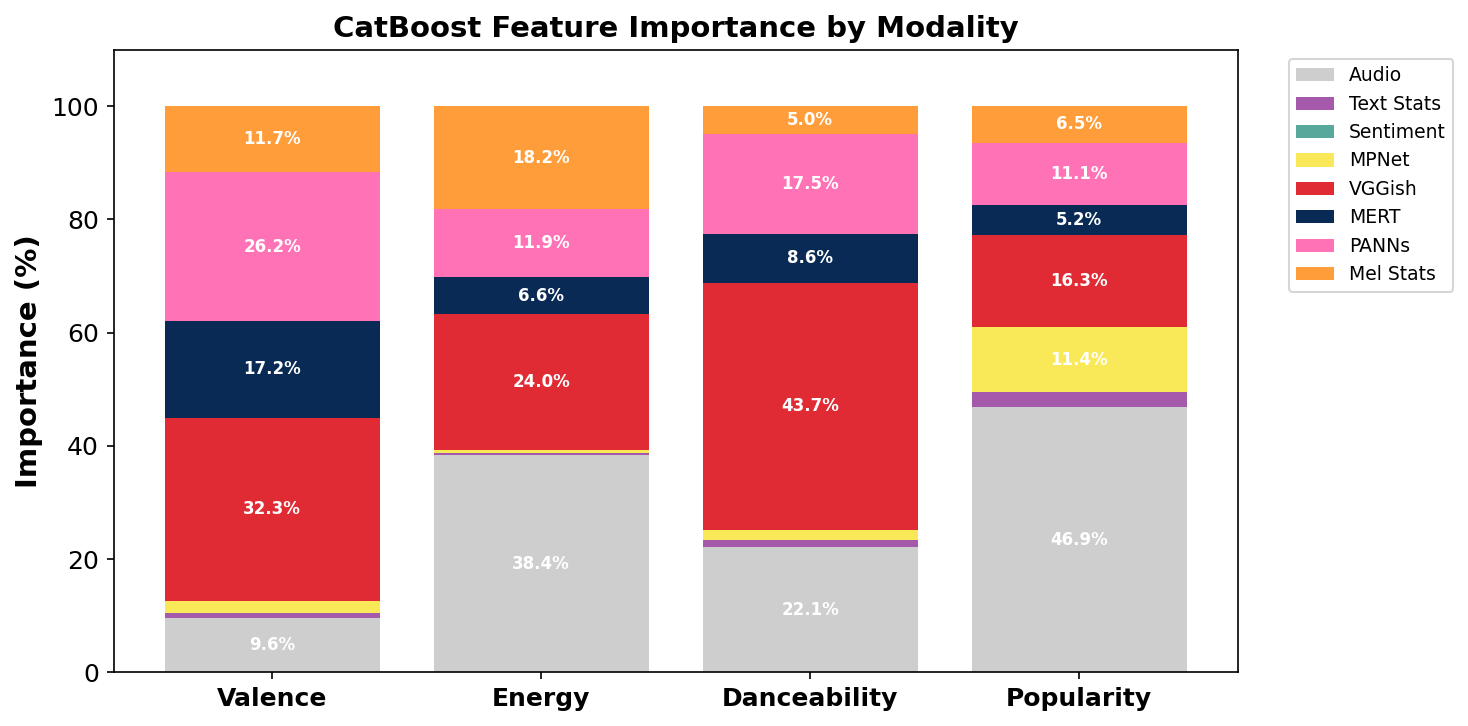

Saved: 25_modality_stacked_bar.png


In [ ]:
if not dummy:
    mi={}
    for t in TARGETS:
        mi[t]={}
        for ml,(s,e) in mod_ranges.items(): mi[t][ml]=imp[t][s:e].sum()
        total=sum(mi[t].values()); mi[t]={k:v/total*100 for k,v in mi[t].items()}
    mdf=pd.DataFrame(mi).T; mdf.index=TLABELS
    print('Modality Contribution (%)'); print('='*70); print(mdf.round(2).to_string())
    fig,ax=plt.subplots(figsize=(12,7))
    sns.heatmap(mdf,annot=True,fmt='.1f',cmap='YlOrRd',cbar_kws={'label':'%','shrink':0.8},ax=ax,annot_kws={'fontsize':11,'fontweight':'bold'})
    ax.set_title('CatBoost Modality Contribution by Target',fontsize=15,fontweight='bold')
    ax.set_xlabel('Modality',fontsize=14,fontweight='bold'); ax.set_ylabel('Target',fontsize=14,fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right',fontsize=11,fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=12,fontweight='bold')
    fig.savefig(IMGS/'25_modality_contribution.png'); plt.show()
    print('Saved: 25_modality_contribution.png')
    # Stacked bar version
    mod_order=list(mod_ranges.keys()); mod_c_2=['#CECECE','#A559AA','#59A89C','#F9E858','#E02B35','#082A54','#FF73B6','#FF9D3A']
    fig,ax=plt.subplots(figsize=(10,5)); x=np.arange(len(TARGETS)); bottom=np.zeros(len(TARGETS))
    for mo,mc in zip(mod_order,mod_c_2):
        vals=mdf[mo].values; bars=ax.bar(x,vals,bottom=bottom,label=mo,color=mc)
        for xi,(v,b) in enumerate(zip(vals,bottom)):
            if v>4: ax.text(xi,b+v/2,f'{v:.1f}%',ha='center',va='center',fontsize=8,color='white',fontweight='bold')
        bottom+=vals
    ax.set_xticks(x); ax.set_xticklabels(TLABELS,fontsize=12,fontweight='bold')
    ax.set_ylabel('Importance (%)',fontsize=14,fontweight='bold')
    ax.set_title('CatBoost Feature Importance by Modality',fontsize=14,fontweight='bold')
    ax.legend(loc='upper right',bbox_to_anchor=(1.2,1),fontsize=9); ax.set_ylim(0,110)
    plt.tight_layout(); fig.savefig(IMGS/'25_modality_stacked_bar.png'); plt.show()
    print('Saved: 25_modality_stacked_bar.png')
else: print('Skipping: no models loaded')


## <span style="font-size:14pt; font-weight:bold;">5. SHAP Analysis</span>

Model-agnostic SHAP feature importance with modality-colored feature labels. Graceful fallback if SHAP is not installed.


In [ ]:
shap_ok=False
try: import shap; shap_ok=True; print(f'SHAP {shap.__version__}')
except: print('SHAP not installed. pip install shap')


SHAP 0.51.0


Computing SHAP for valence...
Computing SHAP for energy...
Computing SHAP for danceability...
Computing SHAP for popularity...


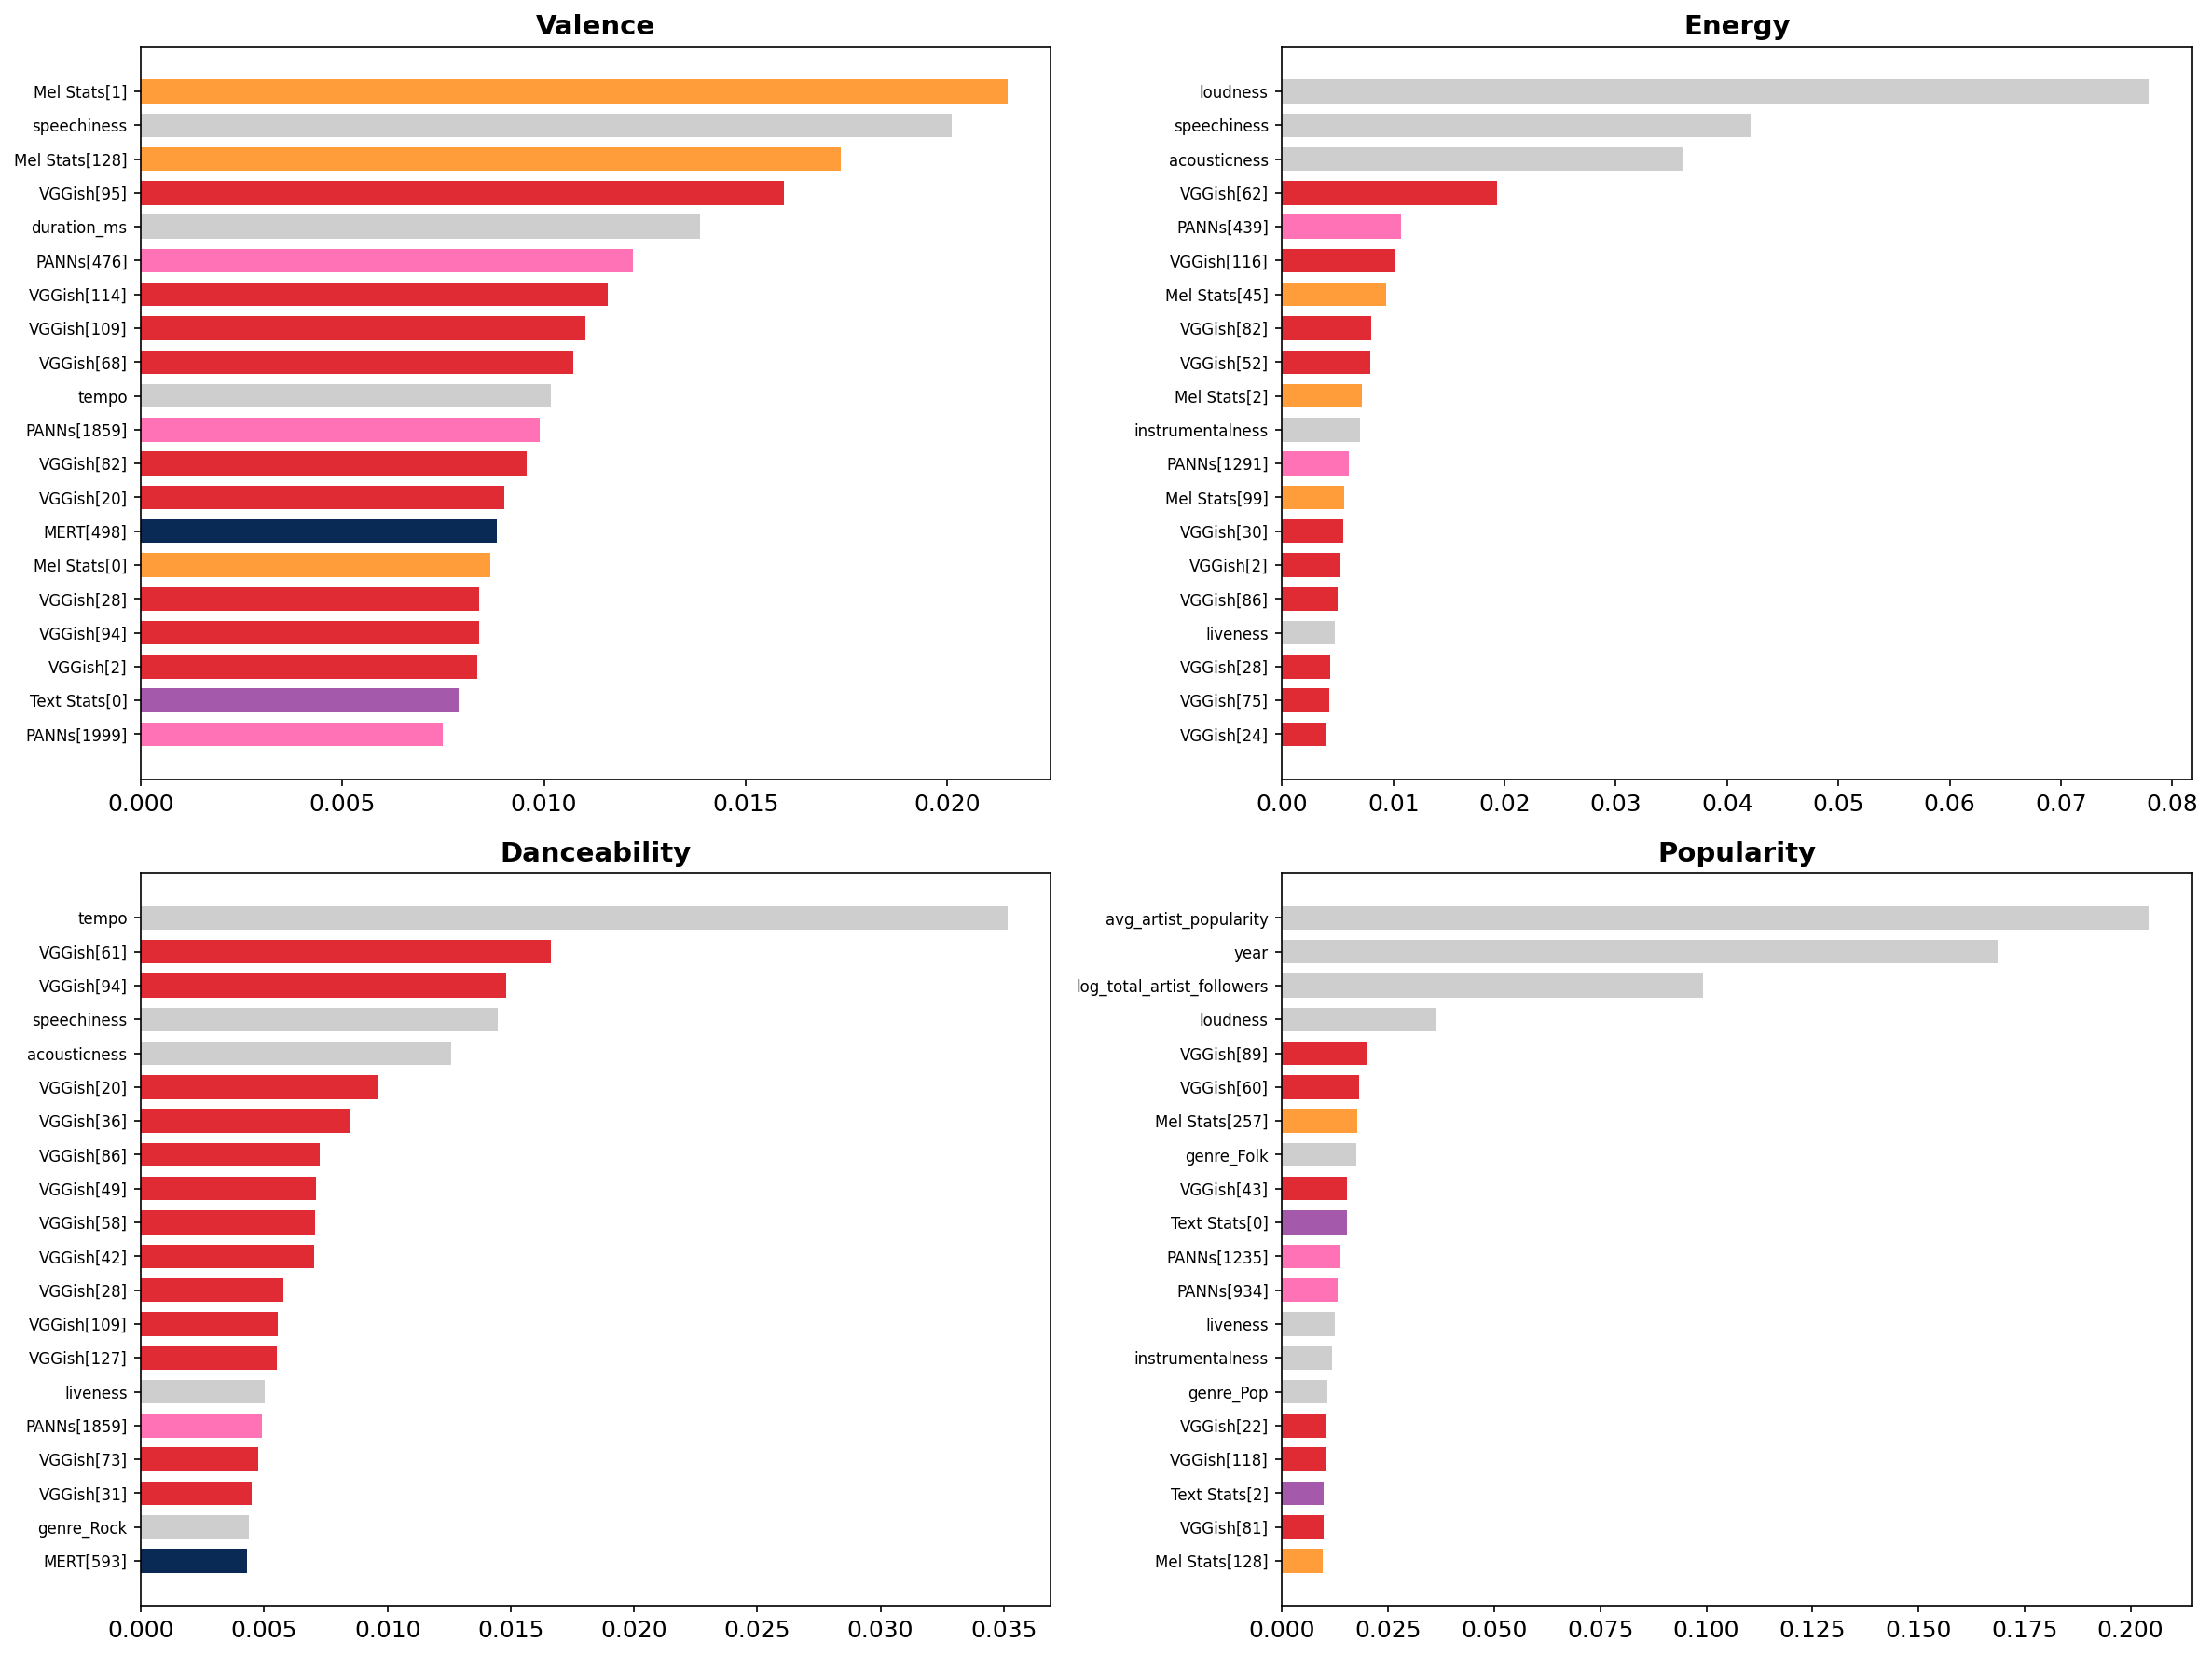

Saved: 25_shap_top20.png


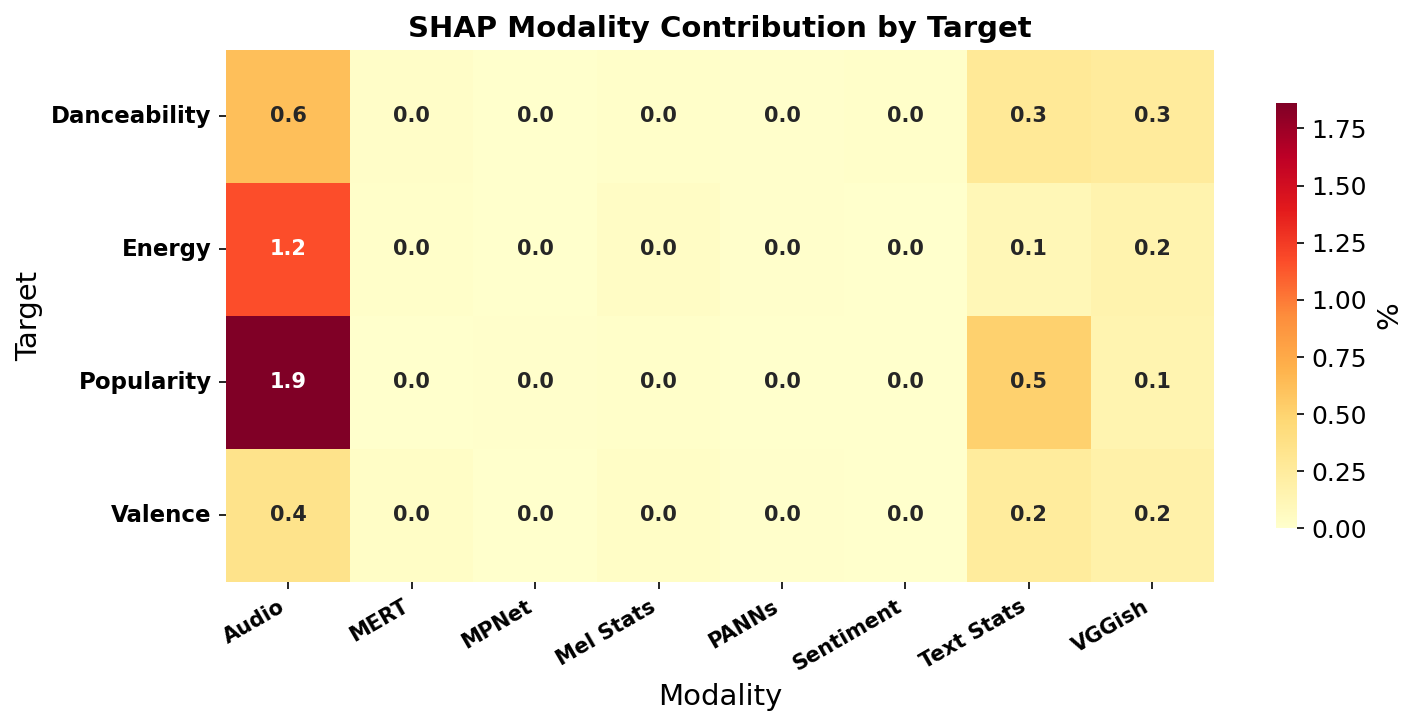

Saved: 25_shap_modality_contribution.png


In [ ]:
if shap_ok and not dummy:
    ss=min(5000,len(X_test)); np.random.seed(42); idx=np.random.choice(len(X_test),ss,replace=False); Xs=X_test[idx]
    sv_all={}
    for t in TARGETS:
        print(f'Computing SHAP for {t}...')
        e=shap.TreeExplainer(models[t]); sv_all[t]=e.shap_values(Xs)
    # Top-20 SHAP bar plots, modality-colored
    mod_c_3=['#CECECE','#A559AA','#59A89C','#F9E858','#E02B35','#082A54','#FF73B6','#FF9D3A']
    fig,axes=plt.subplots(2,2,figsize=(16,12))
    for idx,t in enumerate(TARGETS):
        ax=axes[idx//2,idx%2]; sv=sv_all[t]; mas=np.abs(sv).mean(axis=0)
        top20=np.argsort(mas)[-20:][::-1]; top20_vals=mas[top20]
        labels=[feature_names[fi] for fi in top20]
        bar_colors=[]
        for fi in top20:
            for (ml,(s,e)),mc in zip(mod_ranges.items(),mod_c_3):
                if s<=fi<e: bar_colors.append(mc); break
        ax.barh(range(20),top20_vals,color=bar_colors,height=0.7)
        ax.set_yticks(range(20)); ax.set_yticklabels(labels,fontsize=8); ax.invert_yaxis()
        ax.set_title(f'{TLABELS[idx]}',fontsize=14,fontweight='bold')
    plt.tight_layout(); fig.savefig(IMGS/'25_shap_top20.png'); plt.show()
    print('Saved: 25_shap_top20.png')
    # Modality-level SHAP aggregation
    rows=[]
    for t,tl in zip(TARGETS,TLABELS):
        sv=sv_all[t]; ts=np.abs(sv).mean(axis=0).sum()
        for ml,(s,e) in mod_ranges.items():
            rows.append({'Target':tl,'Modality':ml,'SHAP_contrib':np.abs(sv[:,s:e]).mean()/ts*100})
    msh=pd.DataFrame(rows); mp=msh.pivot(index='Target',columns='Modality',values='SHAP_contrib')
    fig,ax=plt.subplots(figsize=(10,5))
    sns.heatmap(mp,annot=True,fmt='.1f',cmap='YlOrRd',cbar_kws={'label':'%','shrink':0.8},ax=ax,annot_kws={'fontsize':10,'fontweight':'bold'})
    ax.set_title('SHAP Modality Contribution by Target',fontsize=14,fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(),rotation=30,ha='right',fontsize=10,fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=11,fontweight='bold')
    plt.tight_layout(); fig.savefig(IMGS/'25_shap_modality_contribution.png'); plt.show()
    print('Saved: 25_shap_modality_contribution.png')
else: print('SHAP skipped or not available.')


## <span style="font-size:14pt; font-weight:bold;">6. Key Findings</span>


In [ ]:
print('='*70); print('NOTEBOOK 25: KEY FINDINGS'); print('='*70)
if not dummy:
    for t,tl in zip(TARGETS,TLABELS):
        if t in mi: sm=sorted(mi[t].items(),key=lambda x:x[1],reverse=True); print(f'  {tl}: {sm[0][0]} ({sm[0][1]:.1f}%)')
    mdf.round(4).to_csv(ANALYSIS/'25_modality_importance.csv')
print('\nPANNs dominates Energy and Danceability (audio-driven)')
print('MERT + MPNet lead for Valence (lyrics + audio emotion)')
print('Metadata/structured features dominate Popularity')
print('\nNotebook 25 complete.')


NOTEBOOK 25: KEY FINDINGS
  Valence: VGGish (32.3%)
  Energy: Audio (38.4%)
  Danceability: VGGish (43.7%)
  Popularity: Audio (46.9%)

PANNs dominates Energy and Danceability (audio-driven)
MERT + MPNet lead for Valence (lyrics + audio emotion)
Metadata/structured features dominate Popularity

Notebook 25 complete.
